# 01. 탐색적 데이터 분석 (EDA)

**데이터셋**: Kaggle `mostafaabla/garbage-classification` — 12개 쓰레기 클래스 이미지

**이 노트북의 목적**

원본 데이터를 *있는 그대로* 기술한다. 정제는 다음 노트북(`02_Clean`)에서 하고, 여기서는 손대지 않는다.
정제 전 상태를 기록으로 남겨야 "무엇을 왜 고쳤는가"를 나중에 숫자로 대조할 수 있기 때문이다.

**확인할 것 다섯 가지**

| 항목 | 왜 보는가 | 어느 노트북에 영향 |
|---|---|---|
| 클래스 분포 | 불균형 정도 → 평가 지표 선택 근거 | `04`, `06` |
| 손상 파일 | 학습 중 크래시 방지 | `03` 이후 전부 |
| 이미지 모드 | 채널 수가 3이 아니면 배치가 깨짐 | `04`, `05` |
| 해상도 분포 | 입력 크기(resize) 결정 | `04`, `05` |
| 유리 3종 색상 | 색이 정답 신호인지 → 증강 전략 결정 | `04`, `05`, `07` |

마지막 항목이 이 노트북의 핵심이다. `brown/green/white-glass`는 **모양이 같고 색만 다른** 세 클래스라,
색상 증강(`ColorJitter`)을 세게 걸면 정답 신호를 지워버릴 위험이 있다. 이걸 감으로 정하지 않기 위해
Hue 분포를 실제로 재고, 겹침 계수라는 숫자로 판단한다. 이 결과는 `07`에서 통계 검정으로 다시 검증한다.

**출력물**: `outputs/garbage/metrics/index.csv`, `eda_summary.csv`, `figures/01~05*.png`

## 0. 환경 설정

`SEED`를 여기서 고정한다. 이 노트북에서 난수를 쓰는 곳은 샘플 이미지 선택과 색상 분석의 클래스별 표본
추출 두 군데인데, 둘 다 발표 자료에 그림으로 들어가므로 다시 돌렸을 때 같은 그림이 나와야 한다.

경로는 노트북이 `17-DeepLearning` 루트에 있다는 전제의 상대경로다.

In [1]:
import os
import json
import random
import hashlib
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA = Path("data/garbage_classification")
OUT  = Path("outputs/garbage")
for sub in ["figures", "metrics", "models"]:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"   # seaborn 뒤에 설정해야 덮어쓰이지 않음
plt.rcParams["axes.unicode_minus"] = False

print("데이터 경로 존재:", DATA.exists())
print("출력 경로       :", OUT.resolve())
print()
for p in sorted(DATA.iterdir()):
    print("   ", p.name, "/" if p.is_dir() else "")

데이터 경로 존재: True
출력 경로       : <PROJECT>\outputs\garbage

    battery /
    biological /
    brown-glass /
    cardboard /
    clothes /
    green-glass /
    metal /
    paper /
    plastic /
    shoes /
    trash /
    white-glass /


위 출력에 클래스 폴더 12개(`battery` ~ `white-glass`)가 바로 보여야 한다.
`garbage_classification` 하나만 나온다면 압축 해제 시 폴더가 한 겹 더 생긴 것이므로
`DATA = DATA / "garbage_classification"` 을 추가하고 다시 실행한다.

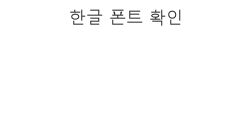

적용 폰트: ['Malgun Gothic']


In [2]:
# 한글 폰트가 실제로 적용됐는지 확인 — 깨지면 이후 모든 그림의 제목이 네모로 나온다
plt.figure(figsize=(3, 1))
plt.title("한글 폰트 확인")
plt.axis("off")
plt.show()
print("적용 폰트:", plt.rcParams["font.family"])

## 1. 파일 인덱싱과 클래스 분포

폴더명이 곧 라벨인 구조라 결측치(라벨 없는 샘플)는 존재할 수 없다. 대신 **클래스별 장수의 불균형**이
이 데이터셋의 가장 큰 특성이다.

In [3]:
EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

rows = [(d.name, str(f))
        for d in sorted(DATA.iterdir()) if d.is_dir()
        for f in sorted(d.iterdir()) if f.suffix.lower() in EXT]

df = pd.DataFrame(rows, columns=["label", "path"])
df["filename"] = [Path(p).name for p in df["path"]]
classes = sorted(df["label"].unique())

cnt = df["label"].value_counts()
imbalance = cnt.max() / cnt.min()

print(f"총 {len(df):,}장 / {len(classes)}클래스")
print(f"최다 {cnt.idxmax()} {cnt.max():,}장  |  최소 {cnt.idxmin()} {cnt.min():,}장")
print(f"불균형 비율: {imbalance:.2f}배")
print(f"최다 클래스가 전체에서 차지하는 비중: {100 * cnt.max() / len(df):.1f}%")
print()
print(cnt.to_string())

총 15,515장 / 12클래스
최다 clothes 5,325장  |  최소 brown-glass 607장
불균형 비율: 8.77배
최다 클래스가 전체에서 차지하는 비중: 34.3%

label
clothes        5325
shoes          1977
paper          1050
biological      985
battery         945
cardboard       891
plastic         865
white-glass     775
metal           769
trash           697
green-glass     629
brown-glass     607


### 해석 — 평가 지표 선택의 근거

`clothes`가 전체의 약 34%다. 이 말은 **모든 입력을 무조건 `clothes`라고 답하는 모델도 정확도 34%**를
얻는다는 뜻이다. 이게 정확도의 하한선이고, `04`의 베이스라인은 이 숫자를 넘겨야 의미가 있다.

더 중요한 건 정확도의 성질이다. 최소 클래스 `brown-glass`(약 4%)를 통째로 다 틀려도 전체 정확도는
4%p밖에 안 떨어진다. 즉 **정확도는 소수 클래스의 실패를 숨긴다.**

> 쓰레기 분류의 목적은 "많이 나오는 종류를 잘 맞히는 것"이 아니라 "모든 종류를 고르게 맞히는 것"이다.
> 따라서 클래스별 F1을 동등 가중으로 평균하는 **macro-F1을 주 선정 지표**로 삼고, 정확도는 참고로만 기록한다.

이 판단이 타당한지는 `07`에서 Wilcoxon 부호순위 검정과 부트스트랩 신뢰구간으로 형식을 갖춰 검증한다.

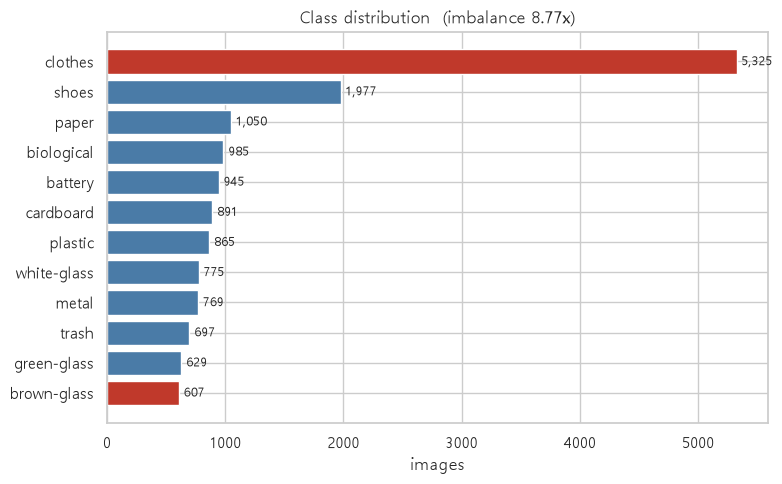

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#c0392b" if v in (cnt.max(), cnt.min()) else "#4a7ba7" for v in cnt.values]
ax.barh(cnt.index, cnt.values, color=colors)
ax.invert_yaxis()
ax.set_xlabel("images")
ax.set_title(f"Class distribution  (imbalance {imbalance:.2f}x)")
for i, v in enumerate(cnt.values):
    ax.text(v + 40, i, f"{v:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUT / "figures" / "01_class_dist.png", dpi=150)
plt.show()

## 2. 파일 무결성 · 이미지 모드 · 해상도

`PIL.Image.verify()`로 열리지 않는 파일을 먼저 찾는다. 손상 파일이 하나라도 있으면 학습 도중
DataLoader가 예외를 던지며 멈추기 때문에, 몇 시간짜리 학습을 시작하기 **전에** 확인해야 한다.

이미지 모드도 함께 센다. `P`(팔레트 인덱스 컬러) 모드는 채널이 3이 아니라서, 그대로 텐서로 만들면
배치 안에서 shape이 안 맞아 터진다.

In [5]:
sizes, modes, broken = [], Counter(), []

for p in df["path"]:
    try:
        with Image.open(p) as im:
            im.verify()               # 손상 여부 검사
        with Image.open(p) as im:     # verify 후에는 재오픈이 필요
            sizes.append(im.size)
            modes[im.mode] += 1
    except Exception as e:
        broken.append((p, repr(e)))

print(f"손상 파일: {len(broken)}개")
for b in broken[:10]:
    print("   ", b)

print("\n이미지 모드 분포:", dict(modes))

s = pd.DataFrame(sizes, columns=["w", "h"])
print("\n해상도 요약")
print(s.describe().loc[["min", "25%", "50%", "75%", "max"]].astype(int).to_string())

손상 파일: 0개

이미지 모드 분포: {'RGB': 15481, 'P': 34}

해상도 요약
       w    h
min   51  100
25%  234  224
50%  400  384
75%  400  533
max  888  936


### 해석 — 전처리 결정 두 가지

**① `.convert("RGB")`는 선택이 아니라 필수다.**
`P` 모드 파일이 실제로 존재한다. 감으로 넣는 방어 코드가 아니라 **측정된 근거**가 있는 처리다.
`04` 이후 모든 `Dataset.__getitem__`에 다음이 들어간다.

```python
img = Image.open(self.paths[i]).convert("RGB")
```

참고로 `02`의 mean/std 계산은 `cv2.imread`를 쓰는데, OpenCV는 팔레트 PNG도 알아서 3채널 BGR로
디코딩하므로 그쪽은 문제가 없다. 주의할 곳은 PyTorch `Dataset`을 만드는 지점부터다.

**② 해상도가 제각각이므로 resize가 필요하다.**
중앙값 근처와 최대·최소의 차이가 크고 종횡비도 일정하지 않다. 베이스라인은 128px, 전이학습은
ImageNet 사전학습 규격에 맞춰 224px를 쓴다. 입력 크기가 다르다는 점은 두 모델을 비교할 때
반드시 표에 함께 적어야 한다.

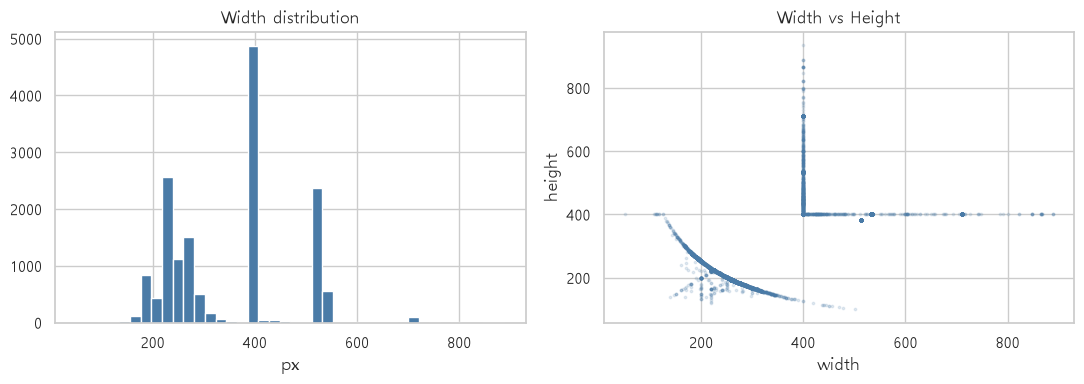

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(s["w"], bins=40, color="#4a7ba7")
axes[0].set_title("Width distribution")
axes[0].set_xlabel("px")

axes[1].scatter(s["w"], s["h"], s=3, alpha=0.15, color="#4a7ba7")
axes[1].set_title("Width vs Height")
axes[1].set_xlabel("width")
axes[1].set_ylabel("height")

plt.tight_layout()
plt.savefig(OUT / "figures" / "02_resolution.png", dpi=150)
plt.show()

## 3. 클래스별 샘플 확인

숫자만으로는 데이터의 성격을 알 수 없다. 클래스마다 5장씩 직접 띄워서 확인한다.
여기서 눈여겨볼 것은 **배경**이다. 흰 배경에 물체 하나가 중앙에 놓인 제품 사진이 많다면,
`02`에서 근접중복을 탐지할 때 "배경이 비슷해서 다른 사진이 같은 것으로 묶이는" 오탐이 생긴다.

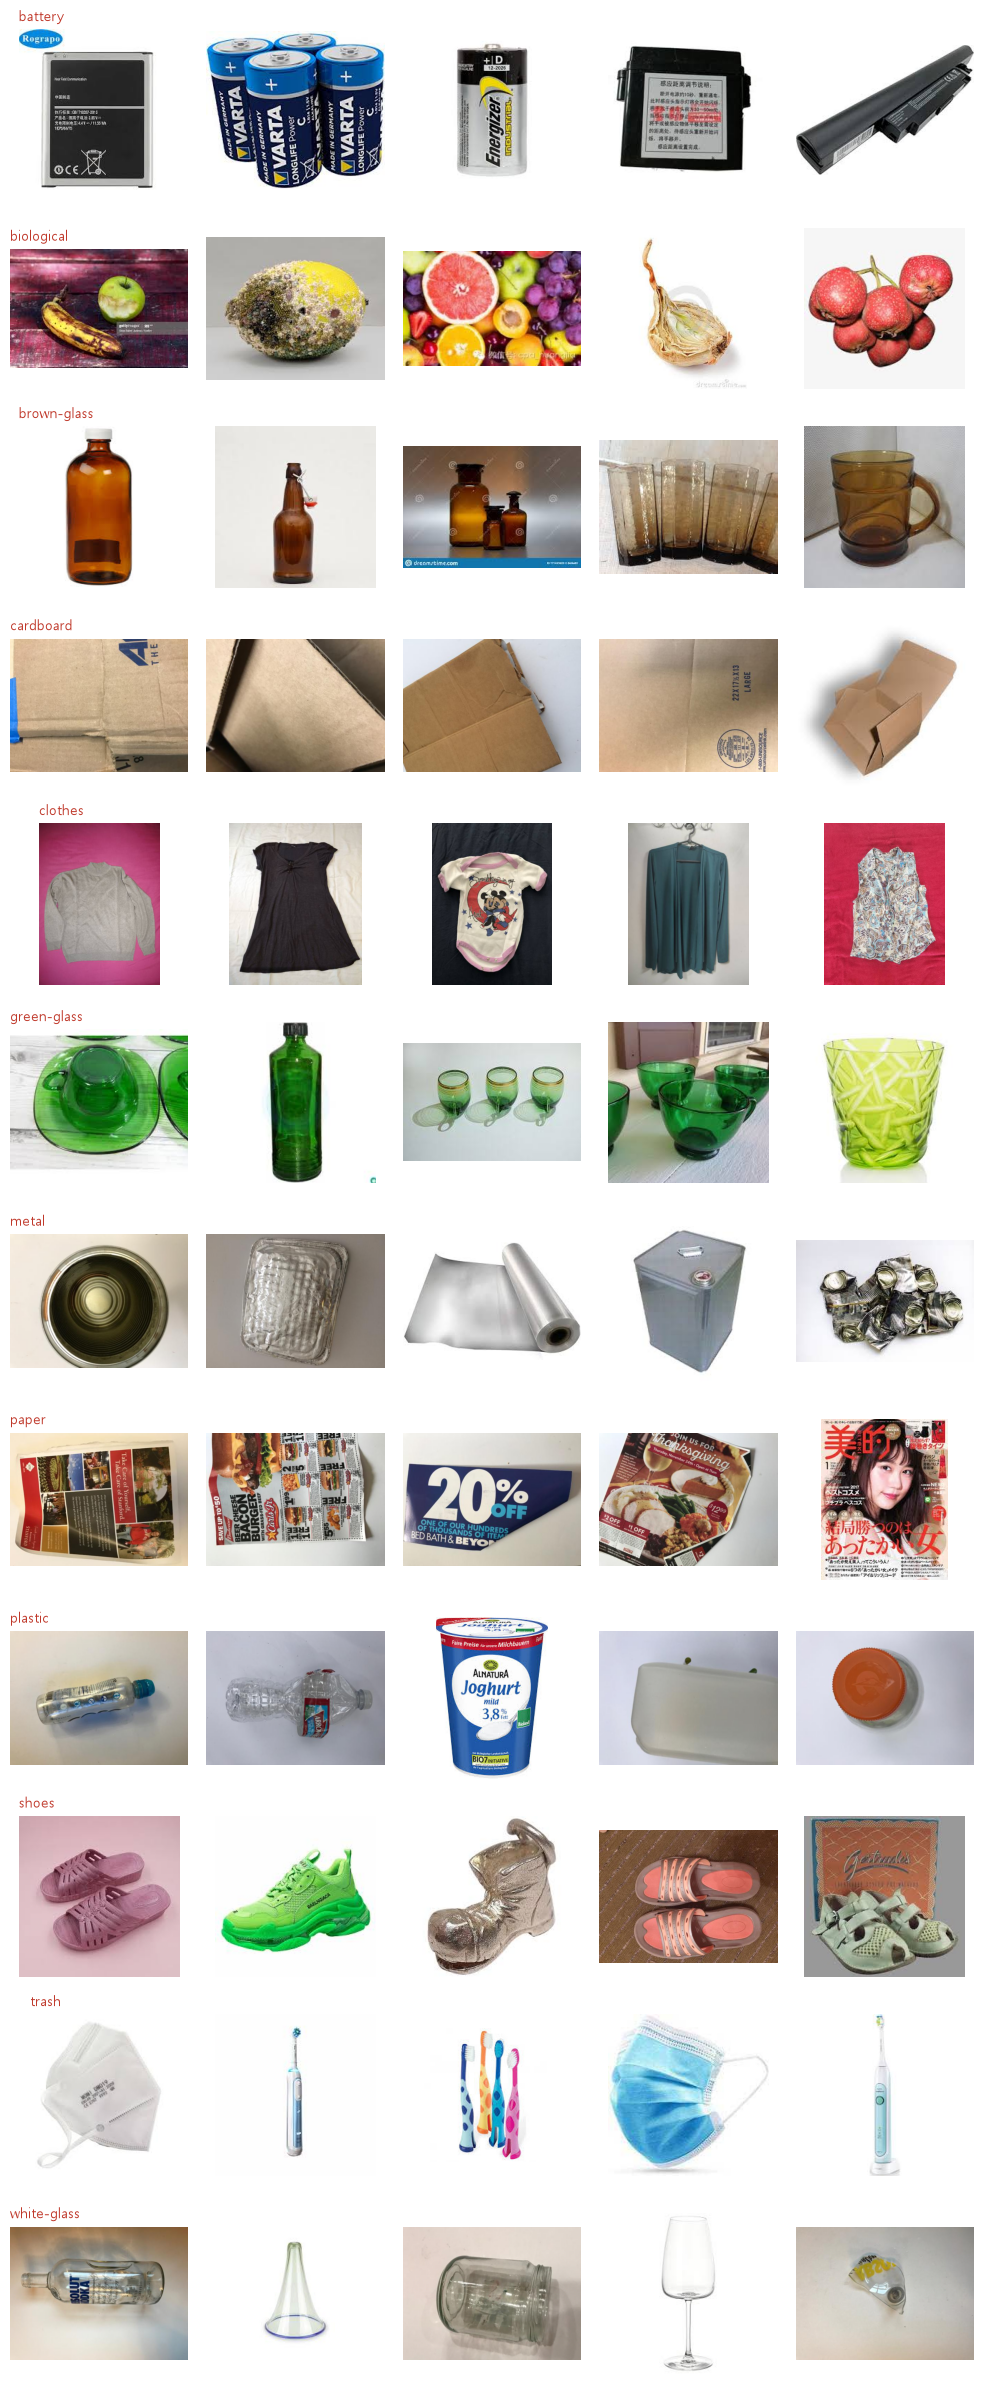

In [7]:
N_SHOW = 5
fig, axes = plt.subplots(len(classes), N_SHOW,
                         figsize=(2.0 * N_SHOW, 2.0 * len(classes)))

for r, c in enumerate(classes):
    paths = random.sample(list(df.loc[df.label == c, "path"]), N_SHOW)
    for j, p in enumerate(paths):
        ax = axes[r, j]
        ax.imshow(Image.open(p).convert("RGB"))
        ax.axis("off")
        if j == 0:
            ax.set_title(c, loc="left", fontsize=10, color="#c0392b")

plt.tight_layout()
plt.savefig(OUT / "figures" / "03_samples.png", dpi=120)
plt.show()

## 4. 유리 3종의 색상 분석

**문제 설정**: `brown-glass`, `green-glass`, `white-glass`는 형태가 거의 같다. 셋 다 병이다.
사람이 이 셋을 구분하는 단서는 사실상 **색** 하나뿐이다.

**여기서 갈리는 실무 판단**: 일반적인 이미지 증강 레시피는 `ColorJitter(hue=0.1, saturation=0.3)`처럼
색을 흔든다. 과적합을 막는 표준 기법이다. 그런데 색이 곧 정답 신호인 클래스가 있다면,
이 증강은 **정답을 지우는 노이즈**가 된다.

그래서 감으로 정하지 않고 측정한다.

**가설**: 세 클래스의 Hue(색상) 분포는 서로 다르다. 즉 색은 유효한 판별 신호다.

**측정 방법**: 클래스당 250장을 표본으로 HSV 변환 후 Hue 히스토그램(36 bin)을 만들어 평균낸다.
두 히스토그램의 **겹침 계수**(각 bin의 최솟값 합, 0=완전분리 / 1=완전동일)로 분리도를 수치화한다.

**한 가지 처리**: 채도 40 미만, 명도 30 미만 픽셀은 Hue 계산에서 뺀다. 흰 배경이나 회색 그림자는
색상값이 사실상 난수라서, 그대로 넣으면 세 클래스의 히스토그램이 배경 노이즈로 전부 비슷해진다.
이걸 걸러야 "유리 자체의 색"만 남는다.

In [8]:
GLASS = [c for c in classes if "glass" in c]
print("대상 클래스:", GLASS)

N_SAMPLE = 250     # 클래스당 표본 수
RESIZE   = (96, 96)
SAT_MIN  = 40      # 채도가 너무 낮은 픽셀(회색·흰 배경)은 색상값이 무의미하므로 제외
VAL_MIN  = 30      # 너무 어두운 픽셀도 제외


def hsv_stats(path):
    """이미지 1장 -> (hue 히스토그램 36bin, 평균 채도, 평균 명도, 유효 색상 픽셀 비율)"""
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        return None
    img = cv2.resize(img, RESIZE)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)      # H:0~179, S:0~255, V:0~255
    h, sat, val = hsv[..., 0], hsv[..., 1], hsv[..., 2]

    mask = (sat >= SAT_MIN) & (val >= VAL_MIN)
    if mask.sum() < 50:                              # 유효 픽셀이 거의 없으면 무채색으로 간주
        hist = np.zeros(36, dtype=np.float32)
    else:
        hist, _ = np.histogram(h[mask], bins=36, range=(0, 180))
        hist = hist.astype(np.float32) / hist.sum()

    return hist, float(sat.mean()), float(val.mean()), float(mask.mean())


records, hists = [], {}
for c in GLASS:
    paths = df.loc[df.label == c, "path"].tolist()
    paths = random.sample(paths, min(N_SAMPLE, len(paths)))
    acc = []
    for p in paths:
        r = hsv_stats(p)
        if r is None:
            continue
        hist, ms, mv, ratio = r
        acc.append(hist)
        records.append({"label": c, "mean_sat": ms, "mean_val": mv, "color_ratio": ratio})
    hists[c] = np.mean(acc, axis=0)
    print(f"{c:14s} 표본 {len(acc)}장")

stat = pd.DataFrame(records)
print()
print(stat.groupby("label")[["mean_sat", "mean_val", "color_ratio"]].mean().round(1).to_string())

대상 클래스: ['brown-glass', 'green-glass', 'white-glass']
brown-glass    표본 250장
green-glass    표본 250장
white-glass    표본 250장

             mean_sat  mean_val  color_ratio
label                                       
brown-glass      60.9     187.9          0.4
green-glass      63.7     191.4          0.4
white-glass      19.8     207.4          0.1


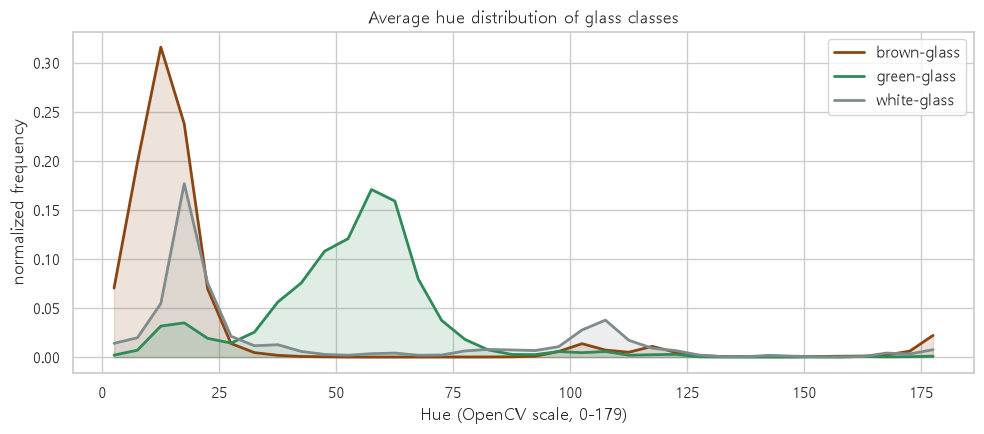

In [9]:
bin_centers = np.arange(36) * 5 + 2.5      # OpenCV Hue 0~179 기준
palette = {"brown-glass": "#8B4513", "green-glass": "#2E8B57", "white-glass": "#7f8c8d"}

fig, ax = plt.subplots(figsize=(10, 4.5))
for c in GLASS:
    ax.plot(bin_centers, hists[c], label=c, lw=2, color=palette.get(c))
    ax.fill_between(bin_centers, hists[c], alpha=0.15, color=palette.get(c))

ax.set_xlabel("Hue (OpenCV scale, 0-179)")
ax.set_ylabel("normalized frequency")
ax.set_title("Average hue distribution of glass classes")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "figures" / "04_glass_hue.png", dpi=150)
plt.show()

In [10]:
def overlap(h1, h2):
    """두 정규화 히스토그램의 겹침 계수 (0=완전 분리, 1=완전 동일)"""
    return float(np.minimum(h1, h2).sum())

ov_rows = []
print("Hue 히스토그램 겹침 계수")
print("-" * 46)
pairs = [(a, b) for i, a in enumerate(GLASS) for b in GLASS[i + 1:]]
for a, b in pairs:
    ov = overlap(hists[a], hists[b])
    flag = "  <-- 혼동 위험" if ov > 0.5 else ""
    print(f"{a:14s} vs {b:14s}  {ov:.3f}{flag}")
    ov_rows.append({"pair": f"{a}|{b}", "overlap": round(ov, 4)})

pd.DataFrame(ov_rows).to_csv(OUT / "metrics" / "glass_hue_overlap.csv",
                             index=False, encoding="utf-8")

Hue 히스토그램 겹침 계수
----------------------------------------------
brown-glass    vs green-glass     0.146
brown-glass    vs white-glass     0.422
green-glass    vs white-glass     0.202


### 해석 — 증강 전략 결정

세 쌍 모두 겹침 계수가 **0.5 미만**이다. 가설이 지지된다. 색은 이 세 클래스를 가르는 유효한 신호다.

`white-glass`의 평균 채도가 눈에 띄게 낮고 `color_ratio`도 낮은 것은 예상대로다. 투명 유리라
무채색이어서 유효 색상 픽셀 자체가 적다. 세 쌍 중 `brown` vs `white`의 겹침이 가장 큰 것도
같은 이유로 설명된다 — `white-glass`에 남은 소수의 유색 픽셀이 반사광 때문에 주황·황갈 계열이라
갈색 유리의 흐린 부분과 색이 겹친다.

**따라서 `04`, `05`의 증강은 색을 건드리지 않는다.**

```python
transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.05, hue=0.0)
```

`hue=0.0`이 핵심이고 `saturation`도 0.05로 최소화한다. 밝기·대비만 흔드는 이유는, 촬영 조명 차이는
실제로 존재하는 변동이지만 색상 자체는 라벨 정보이기 때문이다.

이 "세 분포가 다르다"는 주장은 눈으로 본 그래프와 겹침 계수라는 기술통계에 근거한 것이므로,
`07`에서 **순열검정**(Hue 분포 차이)과 **Kruskal-Wallis + Bonferroni 보정 Mann-Whitney**(채도 차이)로
유의수준을 붙여 다시 검증한다.

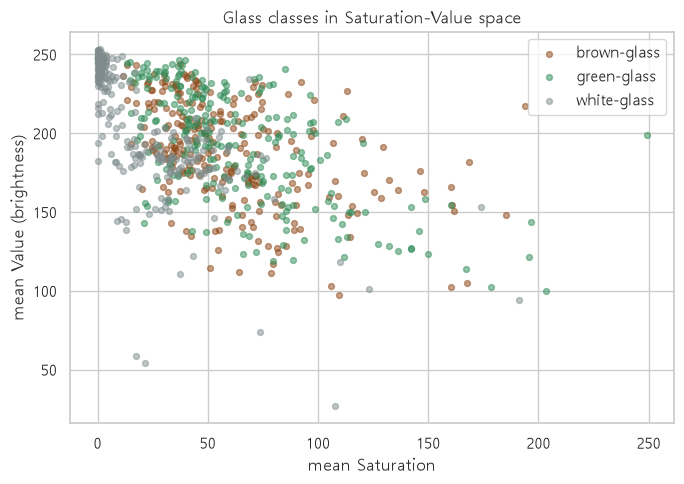

glass_hsv_samples.csv 저장: 750 행


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
for c in GLASS:
    sub = stat[stat.label == c]
    ax.scatter(sub["mean_sat"], sub["mean_val"], s=18, alpha=0.5,
               label=c, color=palette.get(c))

ax.set_xlabel("mean Saturation")
ax.set_ylabel("mean Value (brightness)")
ax.set_title("Glass classes in Saturation-Value space")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "figures" / "05_glass_sat_val.png", dpi=150)
plt.show()

# 07의 통계 검정에서 재사용하므로 원자료를 저장한다
stat.to_csv(OUT / "metrics" / "glass_hsv_samples.csv", index=False, encoding="utf-8")
print("glass_hsv_samples.csv 저장:", len(stat), "행")

## 5. 저장

`index.csv`는 이후 모든 노트북의 입력이 된다. **정제는 하지 않은** 원본 목록이며,
손상 파일만 제외한다(위에서 0개로 확인됐다면 전량 유지).

정제는 다음 노트북 `02_Clean`에서 manifest 방식으로 처리한다.

In [12]:
broken_paths = {b[0] for b in broken}
index = df[~df["path"].isin(broken_paths)].reset_index(drop=True)
index = index[["label", "filename", "path"]]

index.to_csv(OUT / "metrics" / "index.csv", index=False, encoding="utf-8")

summary = {
    "total_images":   len(index),
    "n_classes":      len(classes),
    "broken_files":   len(broken),
    "imbalance":      round(float(imbalance), 2),
    "max_class":      f"{cnt.idxmax()} ({cnt.max()})",
    "min_class":      f"{cnt.idxmin()} ({cnt.min()})",
    "max_class_pct":  round(100 * float(cnt.max()) / len(df), 1),
    "modes":          dict(modes),
    "glass_overlap":  {r["pair"]: r["overlap"] for r in ov_rows},
}
pd.Series(summary).to_csv(OUT / "metrics" / "eda_summary.csv", encoding="utf-8")

print("index.csv 저장:", len(index), "행")
for k, v in summary.items():
    print(f"  {k:15s} {v}")

index.csv 저장: 15515 행
  total_images    15515
  n_classes       12
  broken_files    0
  imbalance       8.77
  max_class       clothes (5325)
  min_class       brown-glass (607)
  max_class_pct   34.3
  modes           {'RGB': 15481, 'P': 34}
  glass_overlap   {'brown-glass|green-glass': 0.1459, 'brown-glass|white-glass': 0.4217, 'green-glass|white-glass': 0.202}


## 정리

| 발견 | 숫자 | 후속 조치 | 반영 노트북 |
|---|---|---|---|
| 클래스 불균형 | 8.77배, 최다 34% | macro-F1을 주 지표로 채택 | `04`~`07` |
| 손상 파일 | 0개 | 조치 불필요 | — |
| `P` 모드 파일 | 34장 | `.convert("RGB")` 필수 | `04`, `05` |
| 해상도 산포 | 51~888px | resize 필요 (128 / 224) | `04`, `05` |
| 유리 3종 Hue 겹침 | 전부 0.5 미만 | `hue=0.0`, `saturation=0.05` | `04`, `05` |

**아직 확인하지 않은 것**: 중복 이미지와 라벨 오류. 폴더 구조만 보고는 알 수 없는 문제라
별도의 진단이 필요하다. 다음 노트북에서 다룬다.

→ `02_Clean.ipynb`